In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open("dano_dataset_travel.csv", "r", encoding="utf-8") as f:
    for i in range(2):
        print(f.readline())

order_online_payment_flg;account_rk;client_rk;order_rk;loyalty_program_type_nm;bundle_nm;order_type_cd;order_status_cd;party_first_order_dt;party_first_order_type_dt;free_cancel_booking_dttm;created_dttm;cancel_dttm;book_start_dttm;local_book_start_dttm;book_end_dttm;hotel_country;hotel_city;avia_dep_city;avia_arr_city;promo_code_discount_amt;loyalty_accrual_rub_amt;nominal_price_eur_amt;nominal_price_rub_amt;order_item_cnt;month_beginning_balance_rub;monthly_income_amt;suppress_email_flg;suppress_call_flg;bounce_cd;last_sms_success_flg;call_contact_6m_flg;call_contact_3m_flg;call_contact_1m_flg;good_email_address_flg;bad_email_address_flg;email_valid_flg;children_cnt;age;age_type_cd;parent_meeting_region_nm;delivery_region_category_cd;lvn_city_nm;lvn_state_nm;time_zone_delta_tm;time_zone_cd;last_used_product_cd;first_used_product_cd;mobile_phone_operator_nm;marital_status_cd;education_level_cd;birth_place;gender_cd;last_sms_dt;last_email_send_dt;last_session_dttm

1,0;209c833731e84d21

**Разделитель - ;**

In [3]:
df = pd.read_csv("dano_dataset_travel.csv", sep=';')

C:\Users\Petr\AppData\Local\Temp\ipykernel_28988\1195759353.py:1: DtypeWarning: Columns (31,32,33,45) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dano_dataset_travel.csv", sep=';')


# Беглый взгляд на данные

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 56 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   order_online_payment_flg     786885 non-null  object 
 1   account_rk                   835938 non-null  object 
 2   client_rk                    835938 non-null  object 
 3   order_rk                     835938 non-null  object 
 4   loyalty_program_type_nm      754957 non-null  object 
 5   bundle_nm                    588049 non-null  object 
 6   order_type_cd                786885 non-null  object 
 7   order_status_cd              779514 non-null  object 
 8   party_first_order_dt         786885 non-null  object 
 9   party_first_order_type_dt    786767 non-null  object 
 10  free_cancel_booking_dttm     75600 non-null   object 
 11  created_dttm                 786885 non-null  object 
 12  cancel_dttm                  0 non-null       float64
 13 

In [5]:
# Процент NaN
nan_percent = df.isna().mean() * 100
print(nan_percent.sort_values())

suppress_email_flg               0.000000
time_zone_cd                     0.000000
time_zone_delta_tm               0.000000
delivery_region_category_cd      0.000000
email_valid_flg                  0.000000
suppress_call_flg                0.000000
last_session_dttm                0.000000
order_rk                         0.000000
client_rk                        0.000000
account_rk                       0.000000
age                              0.000120
last_used_product_cd             0.000359
age_type_cd                      0.029667
mobile_phone_operator_nm         0.148336
last_sms_success_flg             0.239133
last_sms_dt                      0.239133
first_used_product_cd            0.294280
birth_place                      0.354691
gender_cd                        1.215042
book_start_dttm                  5.868019
order_type_cd                    5.868019
created_dttm                     5.868019
nominal_price_eur_amt            5.868019
nominal_price_rub_amt            5

In [6]:
# Количество уникальных значений (исключая NaN)
count_unique = df.nunique().sort_values()
print(len(count_unique))
count_unique

56


cancel_dttm                         0
order_online_payment_flg            1
call_contact_1m_flg                 1
call_contact_3m_flg                 1
call_contact_6m_flg                 1
gender_cd                           2
email_valid_flg                     2
bad_email_address_flg               2
good_email_address_flg              2
last_sms_success_flg                2
suppress_call_flg                   2
suppress_email_flg                  2
order_type_cd                       2
delivery_region_category_cd         3
age_type_cd                         4
last_used_product_cd                4
education_level_cd                  5
marital_status_cd                   6
order_status_cd                     7
children_cnt                        8
bundle_nm                           9
first_used_product_cd               9
order_item_cnt                      9
bounce_cd                          10
time_zone_delta_tm                 12
time_zone_cd                       23
loyalty_prog

In [7]:
df.sample(10).T

,392205,646920,410511,771868,753219,226806,479886,720843,457445,205727
order_online_payment_flg,"1,0","1,0","1,0","1,0","1,0","1,0","1,0","1,0","1,0","1,0"
account_rk,be730e893f65ad472852cdbf3f8ebb8908cafa40bfb97e...,2ff72444d090ebe52b94cdb5afb33addf5cb47c87f0d9d...,01432600ad7e10ac4c0fc263daedced0a5bf204046a454...,f276d44c91ce056116daaf9916fd6d936693548c0466d2...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,9b78f9b2b6e3e836e224c04672894c955cd75cd684eb90...,e1c8783509605562db17ebb163e2dd5669ce690f318fe4...,caa40235d4b4c791c3f11f23fdd735c93c082018fed758...,eb027498ebdbe46b9603d226f4ad00db3d7627f968e8c4...,d367e5b8659a333e4586af9db4621abe0e9df9bbec8b36...
client_rk,b500b5a5f43e014982a01fa23ce10e57af6e0dbf7d39b0...,8be03f4bedc62da9ef895ef8e75e6824332a3e202f1c01...,d11c434d08c983f42e1eaf2ed7a09ceaad6fccab793db0...,039db96f4cd75b008a23b0ee7d2afe7a7d3b5d3962b7c8...,5c1ea702cabd1274ec2099236f0b34600ccbde1313c895...,f57a1bb188db1699dc1bd1e001127cdd0fa1477374fb44...,02ef84880a6e0384731343bd516be6bdc1e5eaa2239d2c...,9d355bac254b84706019b378dbbf1f22d9b3b80b700027...,68ec8a388155120567ea56450aebfeec31fcfade3189fb...,1f03e7139881bafc16611fc743ef2ffbdafad93e59412b...
order_rk,098e79d4011789fbc775a9bcbec2ccc3f90c0793503f3b...,bad80546354defa9df7067a1c120425e1d887c694c14ab...,1f234dc87626063f1c5e65571b7274a09f7789fb4deb4d...,545a2e53f37d759c82918be482bee0711e4b882700f251...,ea721cc31e7d8f7bf154f98168f62e385d52efc936e2b0...,78c8161060e963d1c665c8af790754cbb30361b3b6add2...,49d8c94888f63fae3bdd14967b8cfa66945476066ab439...,cd901dceb2f77b37a806ade9e4d647ead3328e2b11be6d...,792a0a6e7bdb0ce0dffb5a1d74e0720657abaa3593ba46...,e8f1d5414fa16de321abeda9c1773fdc30fb8cb4e00284...
loyalty_program_type_nm,All Airlines,All Airlines,Tinkoff Black,Bravo,NaN,Tinkoff Black Premium,Tinkoff Black Premium,Tinkoff Black,Bravo,Tinkoff Drive
bundle_nm,Pro,NaN,Pro,NaN,NaN,Premium,Pro,Pro,Pro,Pro
order_type_cd,AIR,AIR,AIR,AIR,AIR,AIR,AIR,HOT,AIR,AIR
order_status_cd,SUC,SUC,SUC,SUC,SUC,SUC,SUC,SUC,SUC,SUC
party_first_order_dt,2022-12-15,2022-11-23,2020-08-20,2021-08-08,2021-04-23,2023-09-26,2019-07-24,2022-12-29,2023-01-08,2021-04-25
party_first_order_type_dt,2023-01-16,2023-06-08,2024-02-24,2021-08-08,2021-06-16,2023-10-15,2019-08-12,2024-03-18,2024-06-09,2021-11-20


# Убираем пробельные символы по бокам и заменяем все текстовые аналоги NaN. Также создаём резрвную копию df, чтобы потом не пришлось заново читать её из файла

In [8]:
df_backup_copy = df.copy(deep=True)

In [9]:
df = df_backup_copy.copy(deep=True)

In [10]:
for col in df.columns: 
    df[col] = df[col].map(lambda x: x.strip() if isinstance(x, str) else x)


list_str_nan = ["", " ", "-", "—", "NaN", "nan", "NULL", "None", "N/A"]
df.replace(list_str_nan, pd.NA, inplace=True)

# Приводим данные к нужным типам

 27  suppress_email_flg           835938 non-null  int64  
 28  suppress_call_flg            835938 non-null  int64  
 29  bounce_cd                    39675 non-null   object 
 30  last_sms_success_flg         833939 non-null  object 
 31  call_contact_6m_flg          271 non-null     object 
 32  call_contact_3m_flg          271 non-null     object 
 33  call_contact_1m_flg          271 non-null     object 
 34  good_email_address_flg       19798 non-null   object 
 35  bad_email_address_flg        19798 non-null   object 
 36  email_valid_flg              835938 non-null  int64      

In [11]:
num_cols = ["promo_code_discount_amt", "nominal_price_eur_amt", "loyalty_accrual_rub_amt", "nominal_price_rub_amt", "order_item_cnt", 
            "month_beginning_balance_rub", "monthly_income_amt", "children_cnt", "age", "time_zone_cd"]

for i in num_cols:
    df[i] = df[i].str.replace(",", ".")
    df[i] = pd.to_numeric(df[i], errors="coerce")

In [12]:
date_cols = ["party_first_order_dt", "party_first_order_type_dt", "party_first_order_type_dt", "free_cancel_booking_dttm", "created_dttm",
             "book_start_dttm", "local_book_start_dttm", "book_end_dttm", "last_sms_dt", "last_email_send_dt", "last_session_dttm"]

for i in date_cols:
    df[i] = pd.to_datetime(df[i], errors="coerce")

In [13]:
date_fg = ["order_online_payment_flg", "last_sms_success_flg", "call_contact_6m_flg", "call_contact_3m_flg", "call_contact_1m_flg",
           "good_email_address_flg", "bad_email_address_flg"] # Исключая suppress_email_flg, suppress_call_flg и email_valid_flg (потому что они int)

for i in date_fg:
    df[i] = df[i].str.replace(",", ".")
    df[i] = pd.to_numeric(df[i], errors="coerce").astype("Int64")

# Повторный беглый просмотр данных

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 56 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   order_online_payment_flg     786885 non-null  Int64         
 1   account_rk                   835938 non-null  object        
 2   client_rk                    835938 non-null  object        
 3   order_rk                     835938 non-null  object        
 4   loyalty_program_type_nm      754957 non-null  object        
 5   bundle_nm                    588049 non-null  object        
 6   order_type_cd                786885 non-null  object        
 7   order_status_cd              779514 non-null  object        
 8   party_first_order_dt         786885 non-null  datetime64[ns]
 9   party_first_order_type_dt    786767 non-null  datetime64[ns]
 10  free_cancel_booking_dttm     75600 non-null   datetime64[ns]
 11  created_dttm              

In [15]:
df.sample(10).T

,720962,810462,433345,37884,201545,21557,505039,66479,65554,439726
order_online_payment_flg,1,1,1,1,1,1,1,1,1,<NA>
account_rk,548372885fe93fa3f7c07cce0c3b1dfdd43e5e8d79f2b8...,ebc9dedb838b0921dc175cafd3b738d8df162f376b91ff...,2a82050956e9dc3bb629b9391d153e64f87279881b5a13...,f84894d128dbb93127ff94e77437d37613ba855087c4b6...,8cbaadb7f8f19c8055ca6cccba571ee7cdbe58166ceb7a...,5a6e62ea60fd3481a925b67a446bb99d67bd2dd0549ae5...,18321c523298364e969c157938d61655e07fd240c54e60...,07ab2422d2d5eb62547944afca123d997b2047ac6fda22...,20015728eed1d335fb4dcf8bcea57066a22a69146facef...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...
client_rk,b2dc160d9b9b2c4b1eee392779ddc38498b054ca25448e...,bf4712a8e8c92699ed1a9dda0575c0a3285d9f128224a0...,68d1d5c279307bcd0d31d292698090ccea5ae97c5780f9...,41254a6f9c5b11d73176e1c48ba477db129f22448b46ad...,3ada29b7ffc4d3f616db0ce0da71597b7e90a816183df2...,dd6787ec6af0651c40d9cbb4f47fea48ef11bd6e3ccb36...,482caab40ff0bd6af87371a4d17fff93ca2d7d1cb7a7b8...,5237e775337236e377d4cba6937835fb35b53819e68b05...,019d6c3b9f319a179777d16126278964083f96eacb5bb4...,0c78ca2689a56a266e6f1e12f359f75c2306603a92b5a0...
order_rk,3b1c14540bdf384d1fb713cbb03f7b51be78def281c311...,f95cb2b9837f4c5e47a59034b8451008b52cc1b9e0e684...,623f1dd934145e60f37185e4f27878fba81130b948f232...,3515e1bbc5c1dfed6968e374cf9870669899783997c618...,7ccc98fe62504bcebd22c91e3b85784d7788ad48bf13d6...,bfcb969a1aa5dd199aff4c91fdd038ce83dd7d84fe8be6...,a1c0da8660fdb2e065c5c921e3b095137222519ed393b6...,65ec50260d9757b15eb5f63b0d1aec1a53096c3fdca902...,3d2cd47d8033f7e7c3def3e675637fd73f1f5d40442906...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...
loyalty_program_type_nm,Tinkoff Black Premium,All Airlines Premium,Tinkoff Black,All Airlines,All Airlines,All Airlines,All Airlines Premium Кредитный,Tinkoff Drive,All Airlines,NaN
bundle_nm,Premium,Premium,NaN,Premium,NaN,Pro,Premium,Pro,Pro,NaN
order_type_cd,HOT,AIR,HOT,AIR,AIR,AIR,AIR,HOT,AIR,NaN
order_status_cd,NaN,SUC,SUC,SUC,SUC,SUC,SUC,SUC,PRC,NaN
party_first_order_dt,2018-09-19 00:00:00,2022-06-01 00:00:00,2024-06-09 00:00:00,2022-12-04 00:00:00,2023-06-06 00:00:00,2021-02-22 00:00:00,2019-12-09 00:00:00,2024-04-16 00:00:00,2023-10-17 00:00:00,NaT
party_first_order_type_dt,2018-09-19 00:00:00,2022-06-01 00:00:00,2024-08-15 00:00:00,2023-03-16 00:00:00,2023-06-06 00:00:00,2021-07-17 00:00:00,2020-09-16 00:00:00,2024-04-16 00:00:00,NaT,NaT


# Функция для быстрого просмотра столбца

1) Процент пустых записей: 9.687440934614768
2) Количество пустых записей: 80981
3) Количество уникальных записей: 36
4) Топ уникальных записей для loyalty_program_type_nm
Tinkoff Black                     289081
Tinkoff Black Premium             189005
All Airlines                      143114
NaN                                80981
Bravo                              41428
All Airlines Premium Кредитный     28634
All Airlines Premium               16277
AllAirLinesDebit                   14824
Tinkoff Black Private               6994
Tinkoff Platinum                    6154
Name: count, dtype: int64:
5) Количество типов записей: loyalty_program_type_nm
<class 'str'>      754957
<class 'float'>     80981
Name: count, dtype: int64


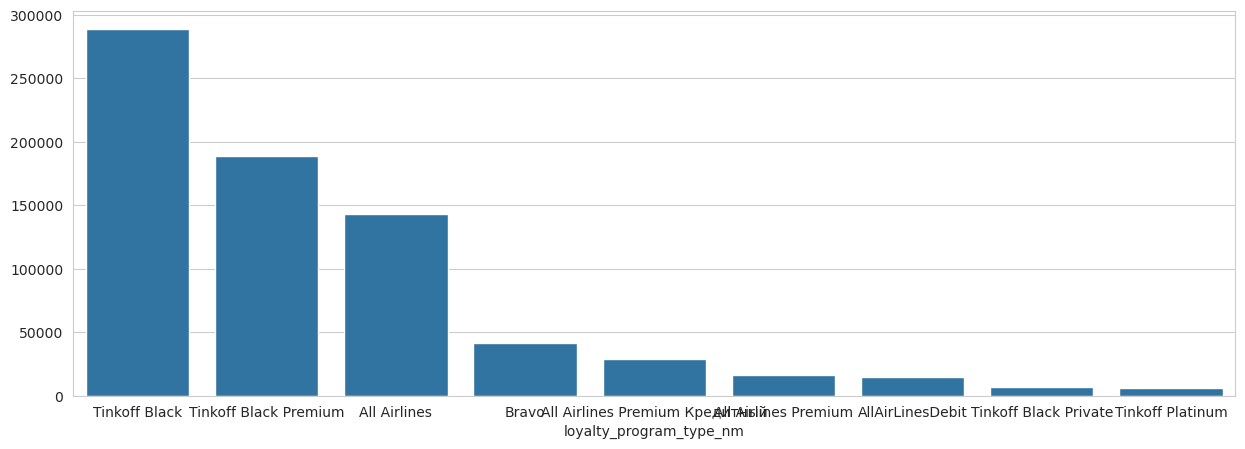

In [16]:
def my_analis(data_set, column, figsize=(10, 5)):
    nan_percent = data_set[column].isna().mean() * 100
    nan_count = data_set[column].isna().sum()
    count_unique = data_set[column].nunique()
    top_values = data_set[column].value_counts(dropna=False, ascending=False).head(count_unique if count_unique <= 10 else 10)
    types = data_set[column].apply(type).value_counts()
    print(f"1) Процент пустых записей: {nan_percent}")
    print(f"2) Количество пустых записей: {nan_count}")
    print(f"3) Количество уникальных записей: {count_unique}")
    print(f"4) Топ уникальных записей для {top_values}:")
    print(f"5) Количество типов записей: {types}")
    with sns.axes_style("whitegrid"):
        plt.figure(figsize=figsize)
        sns.barplot(
            y=top_values.values, 
            x=top_values.index)


my_analis(df, "loyalty_program_type_nm", (15, 5))

# Удаление мало заполненных столбцов и других ненужных столбцов. А также доработка данных.


**Процент незаполненных:**
- children_cnt                    13.905218
- monthly_income_amt              19.482306
- promo_code_discount_amt         26.322287
- order_item_cnt                  26.389637
- avia_dep_city                   26.397053
- avia_arr_city                   26.397053
- bundle_nm                       29.653993
- marital_status_cd               37.688202
- lvn_city_nm                     43.061686
- loyalty_accrual_rub_amt         43.135376
- education_level_cd              43.165163
- book_end_dttm                   79.478382
- hotel_city                      80.590905
- hotel_country                   80.590905
- free_cancel_booking_dttm        90.956267

**Нижнее - УДАЛЯЕМ (много пустых):**
- last_email_send_dt              97.631643
- bad_email_address_flg           97.631643
- good_email_address_flg          97.631643
- call_contact_3m_flg             99.967581
- call_contact_1m_flg             99.967581
- call_contact_6m_flg             99.967581
- cancel_dttm                    100.000000

**Другие столбцы для удаления (эти данные точно не буду сейчас использовать):**
- birth_place - Место рождения
- last_session_dttm - Дата последней сессии
- account_rk - Идентификатор счета
- local_book_start_dttm - Дата заезда в местном часовом поясе (для отелей)
- time_zone_cd - Код часового пояса
- time_zone_delta_tm - Разница часового пояса с Гринвичем

In [17]:
# Мало данных:
cols_to_drop = [
    "last_email_send_dt", "bad_email_address_flg", "good_email_address_flg", "call_contact_3m_flg", "call_contact_1m_flg", 
    "call_contact_6m_flg", "cancel_dttm"]

df2 = df.drop(columns=cols_to_drop)

In [18]:
# Эти данные точно не буду сейчас использовать
cols_to_drop = [
    "birth_place", "last_session_dttm", "account_rk", "local_book_start_dttm", "time_zone_cd", 
    "time_zone_delta_tm"]

df2 = df2.drop(columns=cols_to_drop)

1) Процент пустых записей: 95.25383461452883
2) Количество пустых записей: 796263
3) Количество уникальных записей: 10
4) Топ уникальных записей для bounce_cd
NaN     796263
5,0      25261
15,0      7693
17,0      5403
13,0       400
14,0       366
9,0        257
10,0       192
11,0        62
2,0         25
Name: count, dtype: int64:
5) Количество типов записей: bounce_cd
<class 'float'>    796263
<class 'str'>       39675
Name: count, dtype: int64


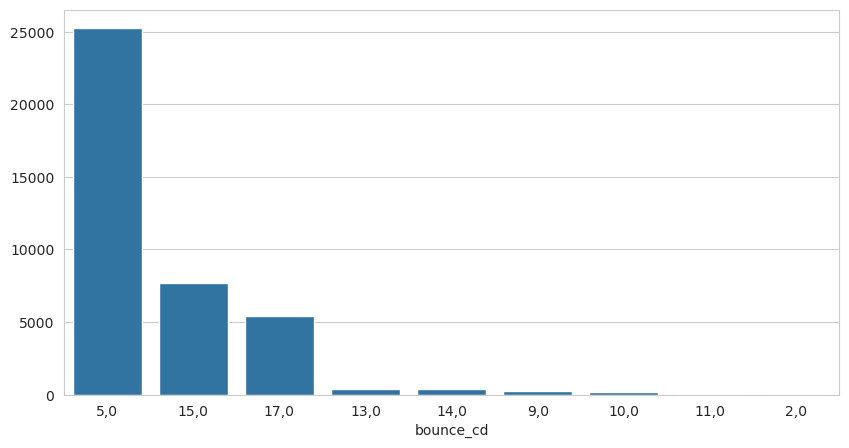

In [19]:
my_analis(df2, "bounce_cd")

bounce_cd - Код smtp-ответа от почтовой системы (отсутствие кода значит успешную отправку, все остальные smtp-коды в открытом доступе)
Тогда заменяем NaN на 1 (доставлено), а остльные занчения на 0 (не доставлено)

In [20]:
df2["bounce_cd"] = df2["bounce_cd"].apply(lambda x: 1 if pd.isna(x) else 0)

In [21]:
nan_percent = df2.isna().mean() * 100
print(nan_percent.sort_values())

client_rk                       0.000000
order_rk                        0.000000
suppress_email_flg              0.000000
delivery_region_category_cd     0.000000
suppress_call_flg               0.000000
email_valid_flg                 0.000000
bounce_cd                       0.000000
age                             0.000120
last_used_product_cd            0.000359
age_type_cd                     0.029667
mobile_phone_operator_nm        0.148336
last_sms_dt                     0.239133
last_sms_success_flg            0.239133
first_used_product_cd           0.294280
gender_cd                       1.215042
nominal_price_rub_amt           5.868019
nominal_price_eur_amt           5.868019
order_online_payment_flg        5.868019
order_type_cd                   5.868019
book_start_dttm                 5.868019
created_dttm                    5.868019
party_first_order_dt            5.868019
party_first_order_type_dt       5.882135
parent_meeting_region_nm        5.919219
lvn_state_nm    

# Соотношение заказов авиабилетов и бронирования отеля

1) Процент пустых записей: 5.86801892006345
2) Количество пустых записей: 49053
3) Количество уникальных записей: 2
4) Топ уникальных записей для order_type_cd
AIR    615337
HOT    171548
Name: count, dtype: int64:
5) Количество типов записей: order_type_cd
<class 'str'>      786885
<class 'float'>     49053
Name: count, dtype: int64


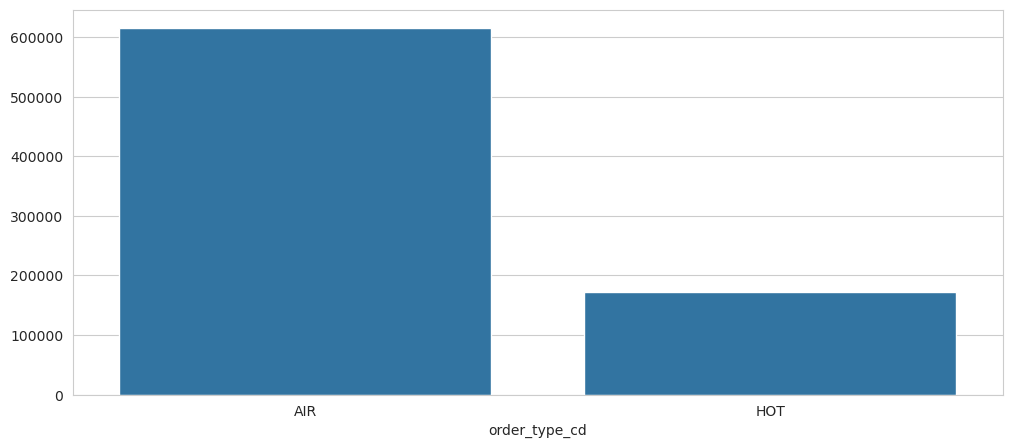

In [22]:
my_analis(df2, "order_type_cd", (12, 5))

# Доля клиентов в дата сете, совершивших покупку

In [23]:
clients_with_SUC = df2.loc[df2['order_status_cd'] == 'SUC']
clients_without_SUC = df2.loc[df2['order_status_cd'] != 'SUC',]

amount_all_clients = df2['client_rk'].nunique()
amount_clients_with_SUC = clients_with_SUC['client_rk'].nunique()


a = amount_clients_with_SUC / amount_all_clients

print(f"Уникальных клиентов всего: {amount_all_clients}")
print(f"Клиентов с покупкой (SUC): {amount_clients_with_SUC}")
print(f"Доля клиентов с покупкой: {a * 100}%")

Уникальных клиентов всего: 148364
Клиентов с покупкой (SUC): 99232
Доля клиентов с покупкой: 66.88414979375051%


C:\Users\Petr\Useful_programs\Anaconda\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


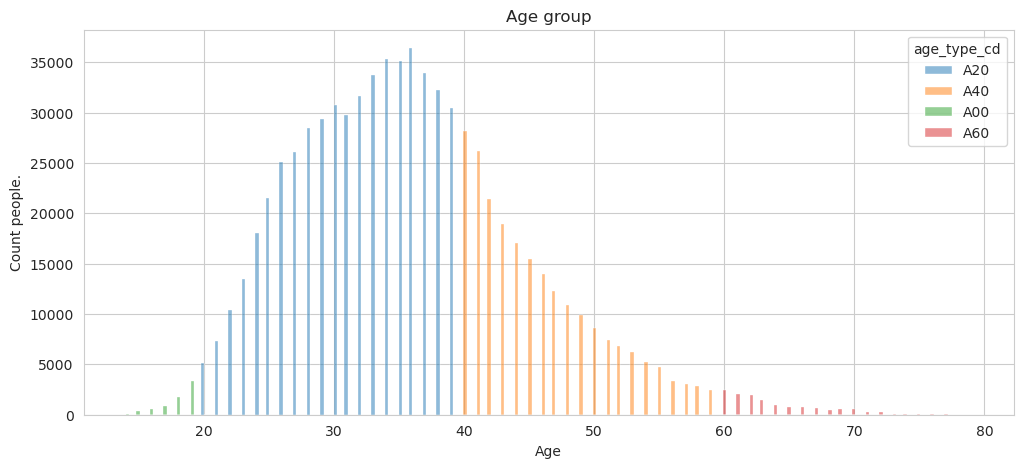

In [157]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(12,5))
    ax = sns.histplot(data=df2[df2['order_status_cd'].isin(["SUC"])], x='age', hue='age_type_cd', kde=False)
    ax.set(xlabel='Age',
           ylabel='Count people.',
           title='Age group'
    )

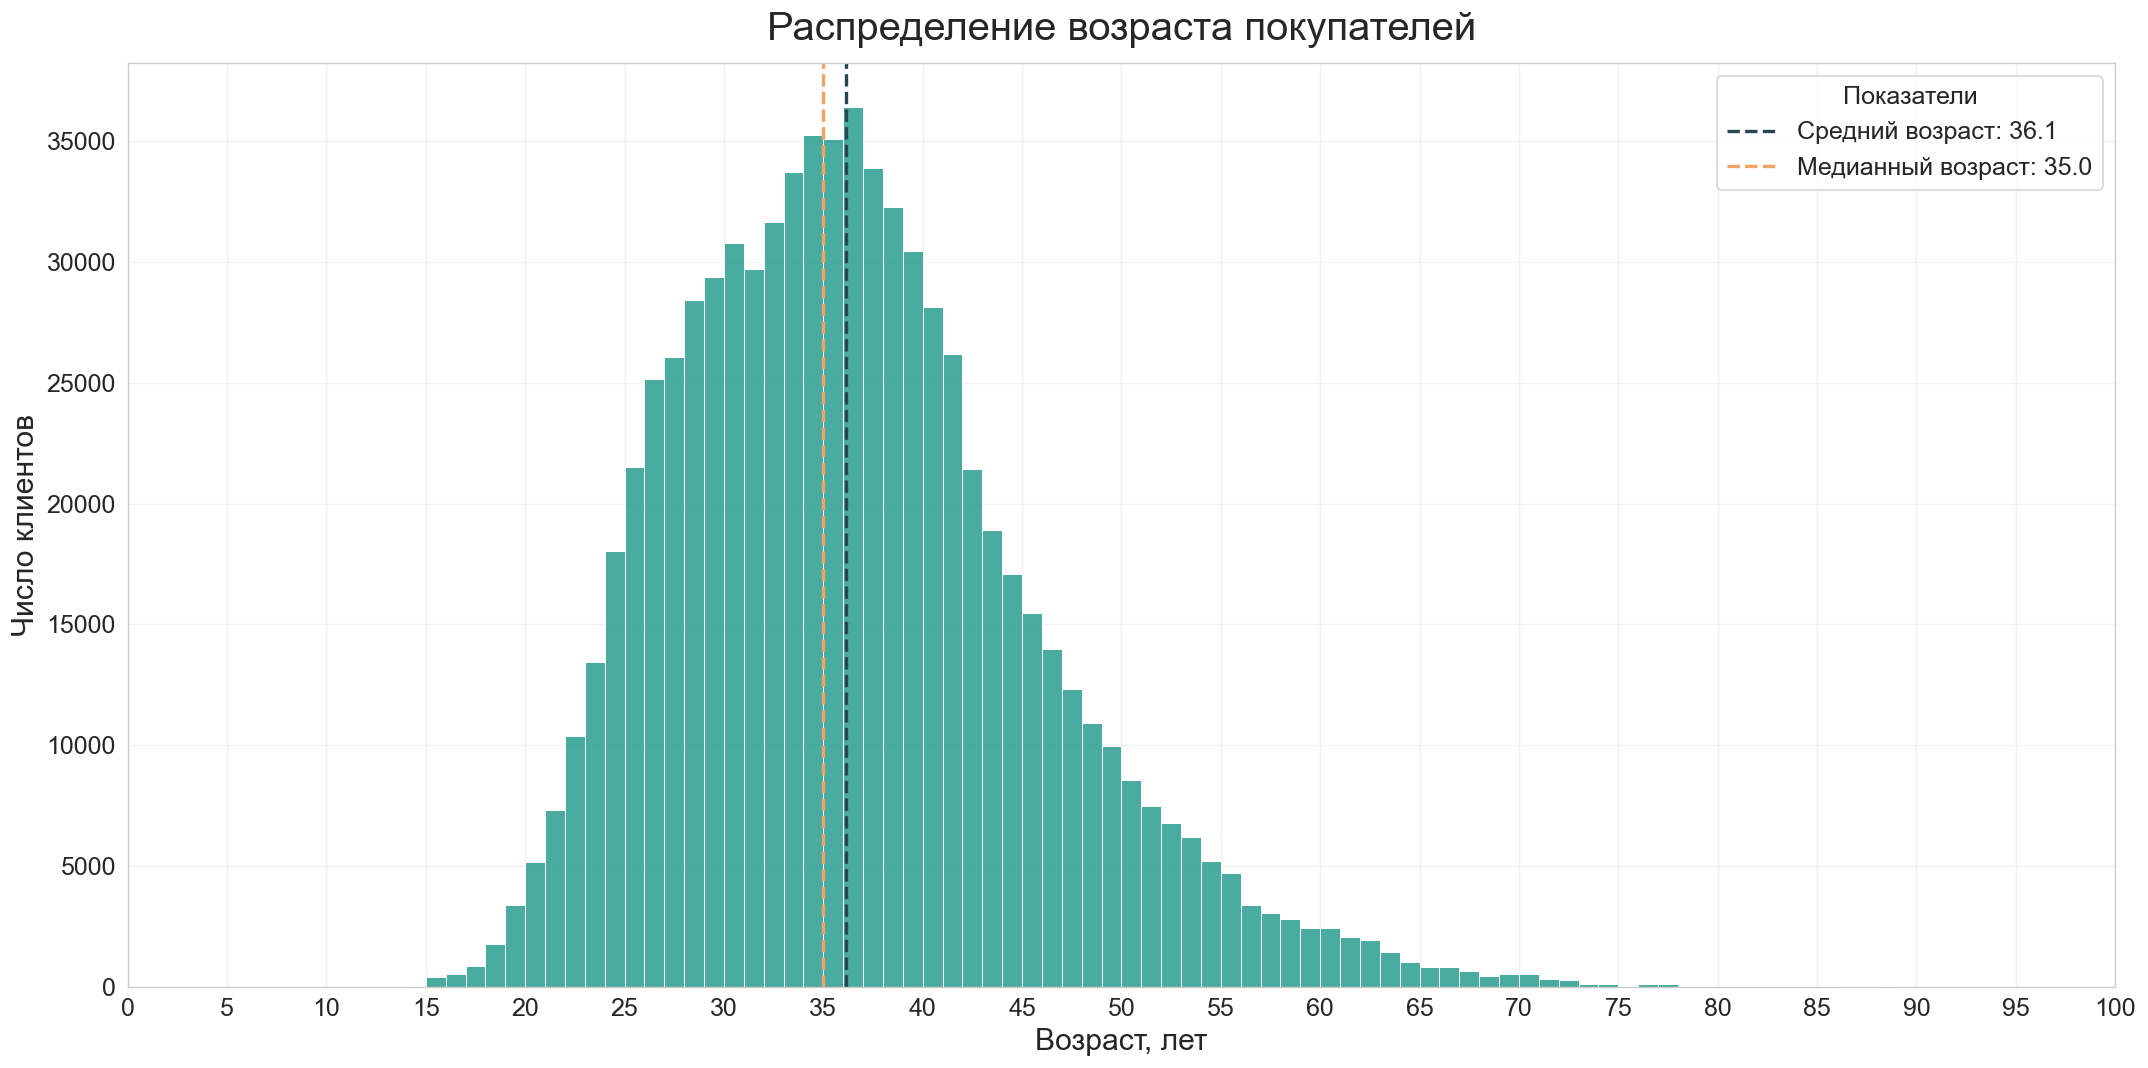

In [146]:
buyers = df2[df2['order_status_cd'].isin(["SUC"])].copy()

mean_age = buyers["age"].mean()
median_age = buyers["age"].median()

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(18, 9), dpi=120)

    # Гистограмма по 1 году
    sns.histplot(
        data=buyers,
        x="age",
        bins=range(0, 101, 1),     # бины по 1 году
        color="#2A9D8F",           # насыщённый бирюзовый
        edgecolor="white",
        linewidth=0.6,
        alpha=0.85,
        stat="count",              # можно заменить на "percent", если нужна доля
        ax=ax
    )

    # Вертикальные линии среднего и медианы
    ax.axvline(mean_age,   color="#264653", linestyle="--", linewidth=2,
               label=f"Средний возраст: {mean_age:.1f}")
    ax.axvline(median_age, color="#F4A261", linestyle="--", linewidth=2,
               label=f"Медианный возраст: {median_age:.1f}")

    # Подписи и оформление
    ax.set_title("Распределение возраста покупателей", fontsize=24, pad=14)
    ax.set_xlabel("Возраст, лет", fontsize=18)
    ax.set_ylabel("Число клиентов", fontsize=18)

    ax.set_xlim(0, 100)
    ax.set_xticks(range(0, 101, 5))
    ax.tick_params(axis="both", labelsize=15)
    ax.grid(True, which="major", alpha=0.25)

    # Легенда
    ax.legend(title="Показатели", title_fontsize=15, fontsize=15, frameon=True, loc="upper right")

    plt.tight_layout()
    plt.show()

In [159]:
tmp = df2.assign(suc = (df2["order_status_cd"] == "SUC").astype("Int64"))

by_client = tmp.groupby(["age_type_cd", "client_rk"], dropna=True)["suc"].max().reset_index()

share_by_age = (by_client.groupby("age_type_cd")["suc"].mean() * 100).sort_index()

age_labels = {
    "A00": "0–19 лет",
    "A20": "20–39 лет",
    "A40": "40–59 лет",
    "A60": "60+ лет"
}

share_by_age = share_by_age.rename(index=age_labels)

print(share_by_age.round(2))

age_type_cd
0–19 лет      23.6
20–39 лет    69.31
40–59 лет    66.93
60+ лет      52.38
Name: suc, dtype: Float64


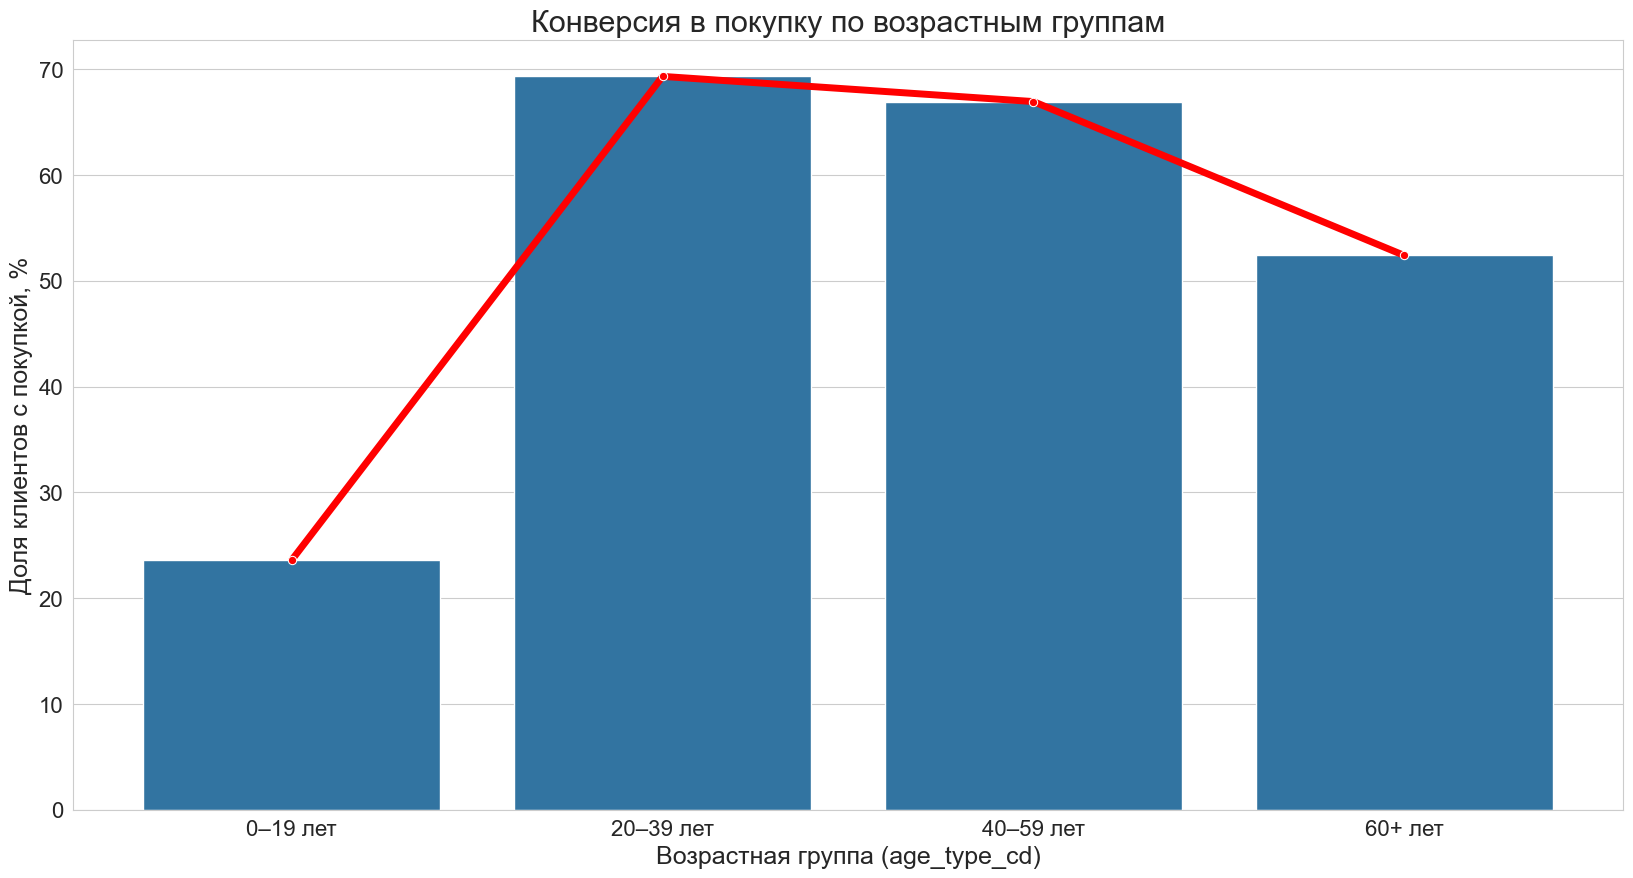

In [160]:
with sns.axes_style("whitegrid"):
    plt.figure(figsize=(20,10))
    sns.barplot(
        y=share_by_age.values,
        x=share_by_age.index
    )
    sns.lineplot(
    x=share_by_age.index,
    y=share_by_age.values,
    color="red",
    marker="o",
    linewidth=5
    )
    plt.xlabel("Возрастная группа (age_type_cd)", fontsize=18)
    plt.ylabel("Доля клиентов с покупкой, %", fontsize=18)
    plt.title("Конверсия в покупку по возрастным группам", fontsize=22)

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.show()

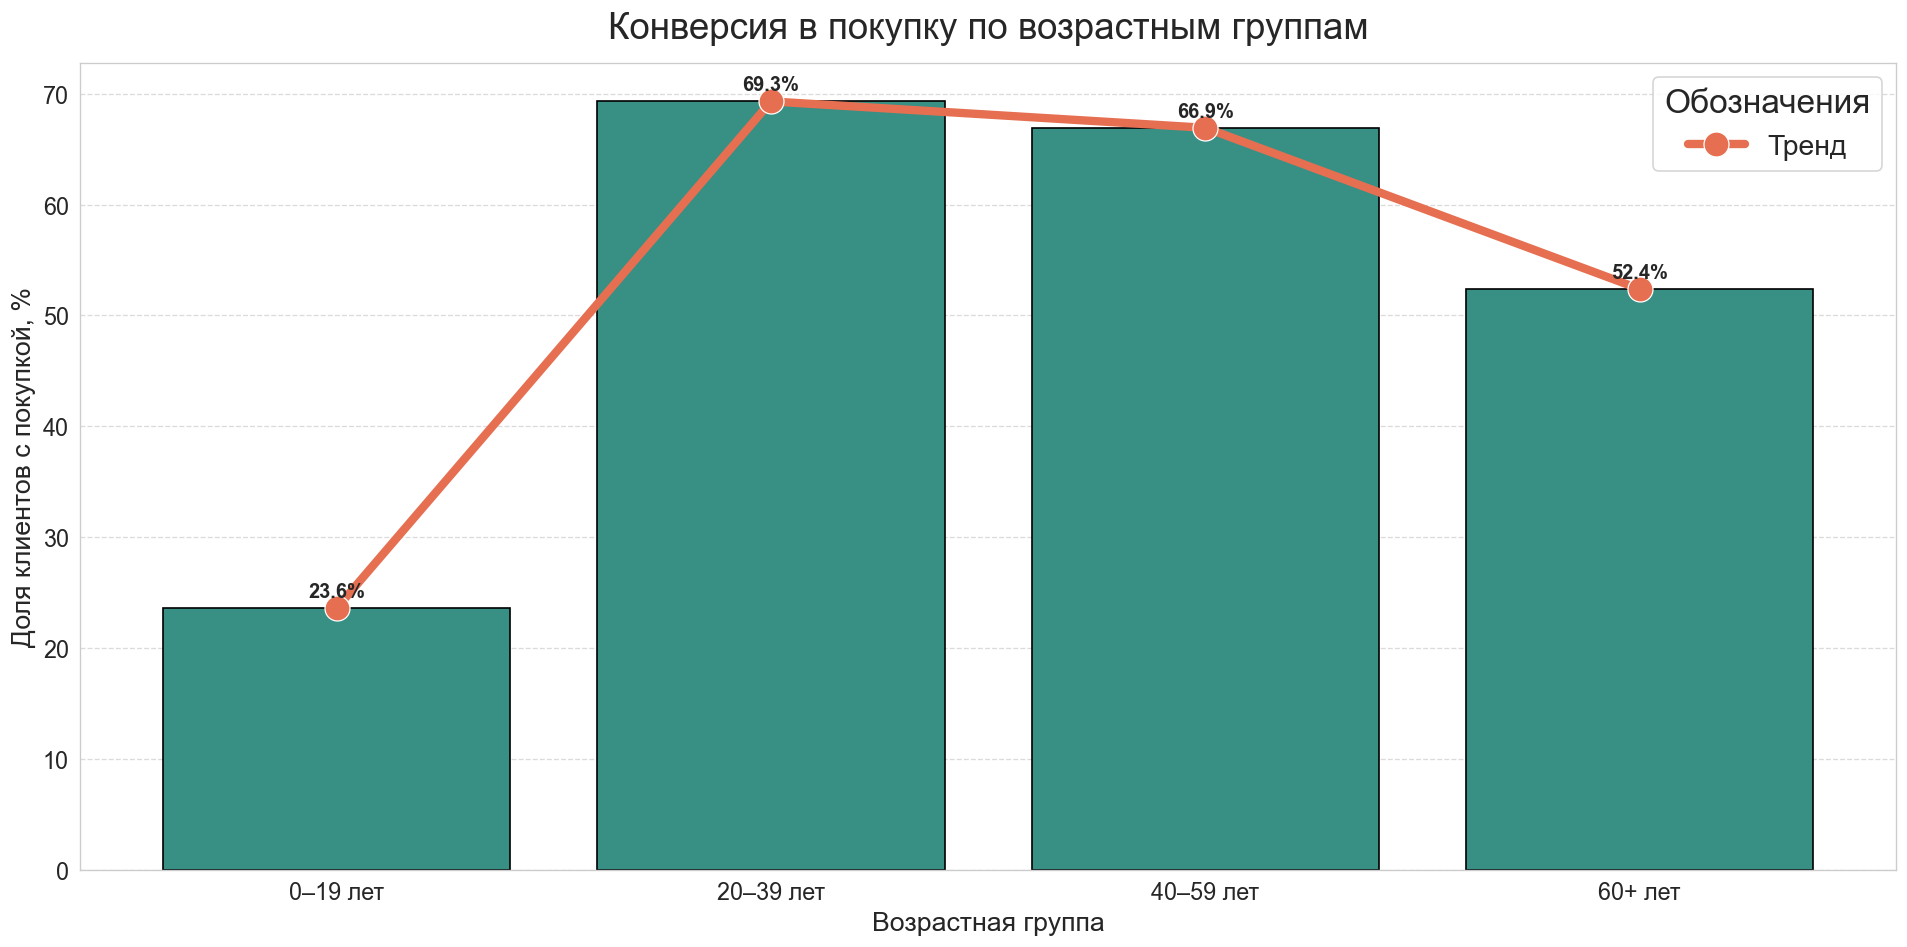

In [161]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(16, 8), dpi=120)

    # 1. Столбчатая диаграмма
    bars = sns.barplot(
        x=share_by_age.index,
        y=share_by_age.values,
        color="#2A9D8F",   # насыщенный бирюзовый
        edgecolor="black",
        ax=ax
    )

    # 2. Линия поверх баров
    sns.lineplot(
        x=share_by_age.index,
        y=share_by_age.values,
        color="#E76F51",   # коралловый для акцента
        marker="o",
        linewidth=5,
        markersize=15,
        ax=ax,
        label="Тренд"
    )

    # 3. Подписи процентов над столбцами
    for idx, value in enumerate(share_by_age.values):
        ax.text(idx, value + 1, f"{value:.1f}%", ha="center", fontsize=12, fontweight="bold")

    # 4. Подписи и оформление
    ax.set_title("Конверсия в покупку по возрастным группам", fontsize=22, pad=15)
    ax.set_xlabel("Возрастная группа", fontsize=16)
    ax.set_ylabel("Доля клиентов с покупкой, %", fontsize=16)

    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)

    # сетка только по горизонтали
    ax.grid(axis="y", linestyle="--", alpha=0.7)

    ax.legend(fontsize=17, title="Обозначения", title_fontsize=20)

    plt.tight_layout()
    plt.show()

In [162]:
tmp = df2.assign(suc = (df2["order_status_cd"] == "SUC").astype("Int64"))

by_client = tmp.groupby(["age", "client_rk"], dropna=True)["suc"].max().reset_index()
by_client

,age,client_rk,suc
0,14.0,02faf9402d922ef6d6cb32aecbbd0f3086a72aac60f3c9...,0
1,14.0,03eca97bf9ccdbe094f8db8fb77b5159e41587349f0a54...,1
2,14.0,07679fc55c1aa61452ec4b188e79d7161a926bd4141194...,0
3,14.0,07b89899d74c1801d35268603435a8d14e2805bfa7afdf...,0
4,14.0,08bdd8e6415dc159a8df61b39cf3f1e932ba1341987e5d...,0
...,...,...,...
148358,89.0,d0c04f56ab8df46437589c74a103a3847f62658898d974...,0
148359,89.0,f4faf06e3bec36a781901fe8a2e28f16abb094d3e34907...,0
148360,90.0,60bc2fc8070d5f28baf4db3f0231130027f2e79e1136b5...,0
148361,92.0,134e1246a628fdb9d5d8f4671e19767c45b1703450a3b3...,0


In [163]:
share_by_age = (by_client.groupby("age")["suc"].mean() * 100).sort_index()
print(share_by_age.round(2))

age
14.0    10.26
15.0    13.01
16.0    15.66
17.0    17.73
18.0    23.22
        ...  
88.0    100.0
89.0      0.0
90.0      0.0
92.0      0.0
98.0    100.0
Name: suc, Length: 79, dtype: Float64


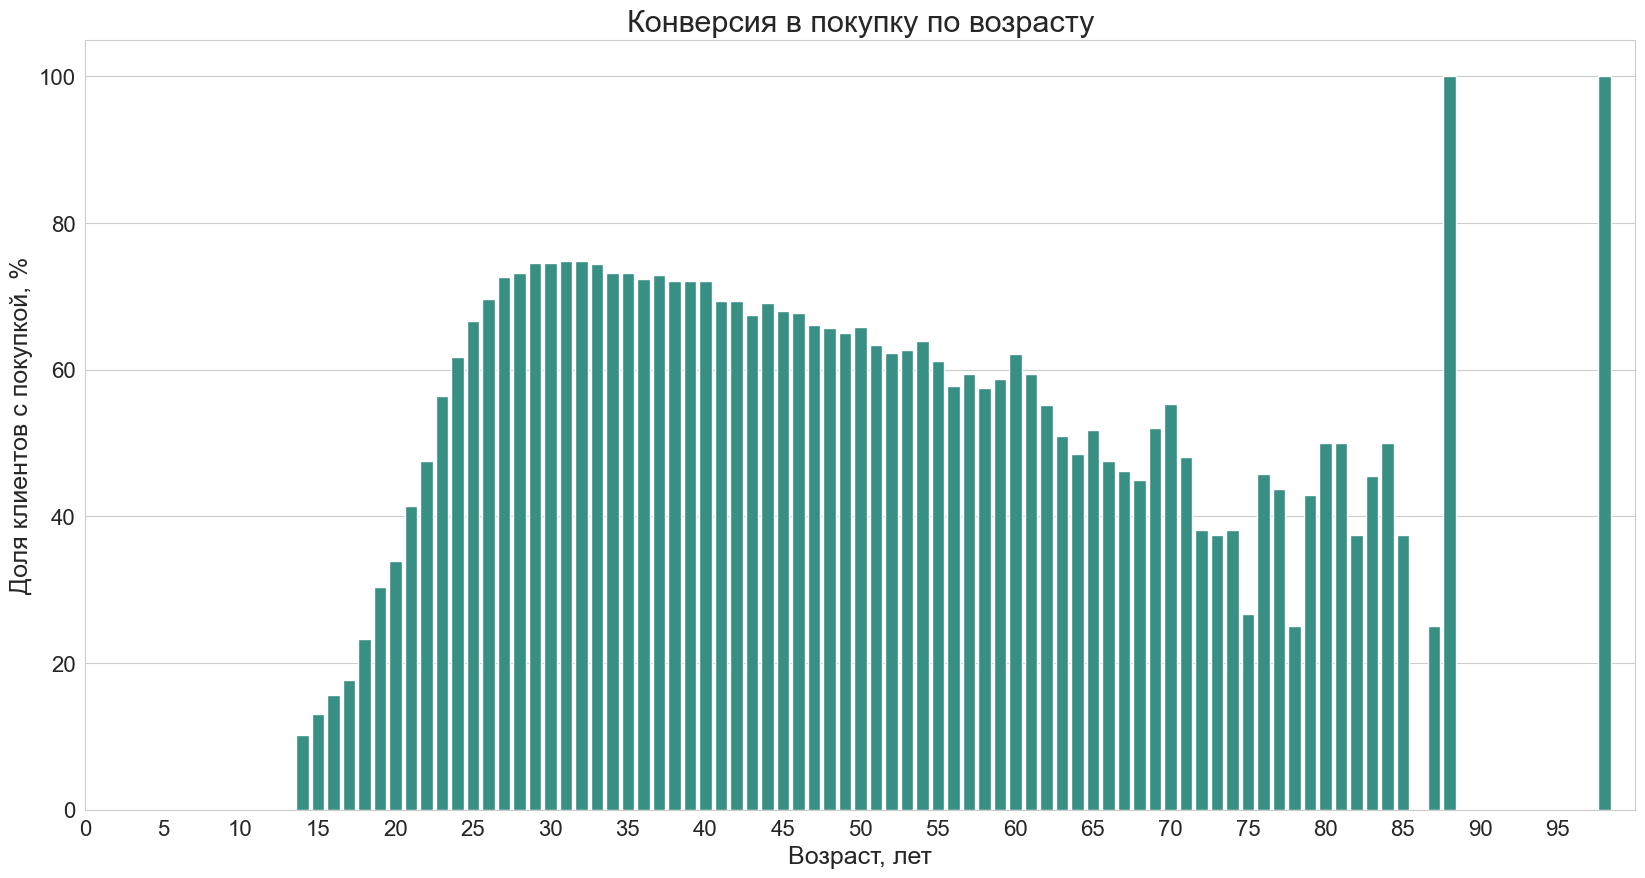

In [164]:
# достаём минимальный и максимальный возраст
min_age = int(share_by_age.index.min())
max_age = int(share_by_age.index.max())

# создаём полный диапазон возрастов от 0 до max_age
full_index = range(0, max_age + 1)

# переиндексируем с заполнением пропусков NaN (там где данных нет)
share_by_age_full = share_by_age.reindex(full_index, fill_value=0)

with sns.axes_style("whitegrid"):
    plt.figure(figsize=(20,10))
    sns.barplot(
        y=share_by_age_full.values,
        x=share_by_age_full.index,
        color="#2A9D8F"
    )

    plt.xlabel("Возраст, лет", fontsize=18)
    plt.ylabel("Доля клиентов с покупкой, %", fontsize=18)
    plt.title("Конверсия в покупку по возрасту", fontsize=22)

    # начинаем ось с 0
    plt.xlim(0, max_age + 1)

    # метки через 5 лет начиная с 0
    step = 5
    plt.xticks(
        ticks=range(0, max_age + step, step),
        fontsize=16
    )

    plt.yticks(fontsize=16)
    plt.show()